# SEGWO Response Analysis — Publication-Ready Figures

This notebook generates all figures for the paper from pre-computed results stored in `./data`.
No heavy computation is performed here; every cell only loads arrays and produces plots.

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import healpy as hp
from matplotlib.colors import LogNorm
from lisaconstants.indexing import LINKS
from lisaconstants import C
from plot_utils import plot_orbit_3d
from segwo_utils import InterpolatedOrbits
from lisaorbits import StaticConstellation

plt.rcParams.update()
# ── Publication-quality matplotlib settings ─────────────────────────────────
plt.rcParams.update({
    'text.usetex':       True,        # set True if a LaTeX install is available
    'font.family':       'times',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'legend.frameon':    True,
    'legend.framealpha': 0.8,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    ':',
    'lines.linewidth':   1.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Figure width constants (inches) ─────────────────────────────────────────
COL1 = 3.5   # single-column
COL2 = 7.2   # double-column

# ── Polarisation labels ──────────────────────────────────────────────────────
POLS = (r'$h_+$', r'$h_\times$')

# ── Output directory for paper-quality PDFs ──────────────────────────────────
PAPER_DIR = "paper_plots"
os.makedirs(PAPER_DIR, exist_ok=True)

3D orbit plot saved to paper_plots/lisa_orbit_.png
3D orbit plot saved to paper_plots/toy_orbit_.png


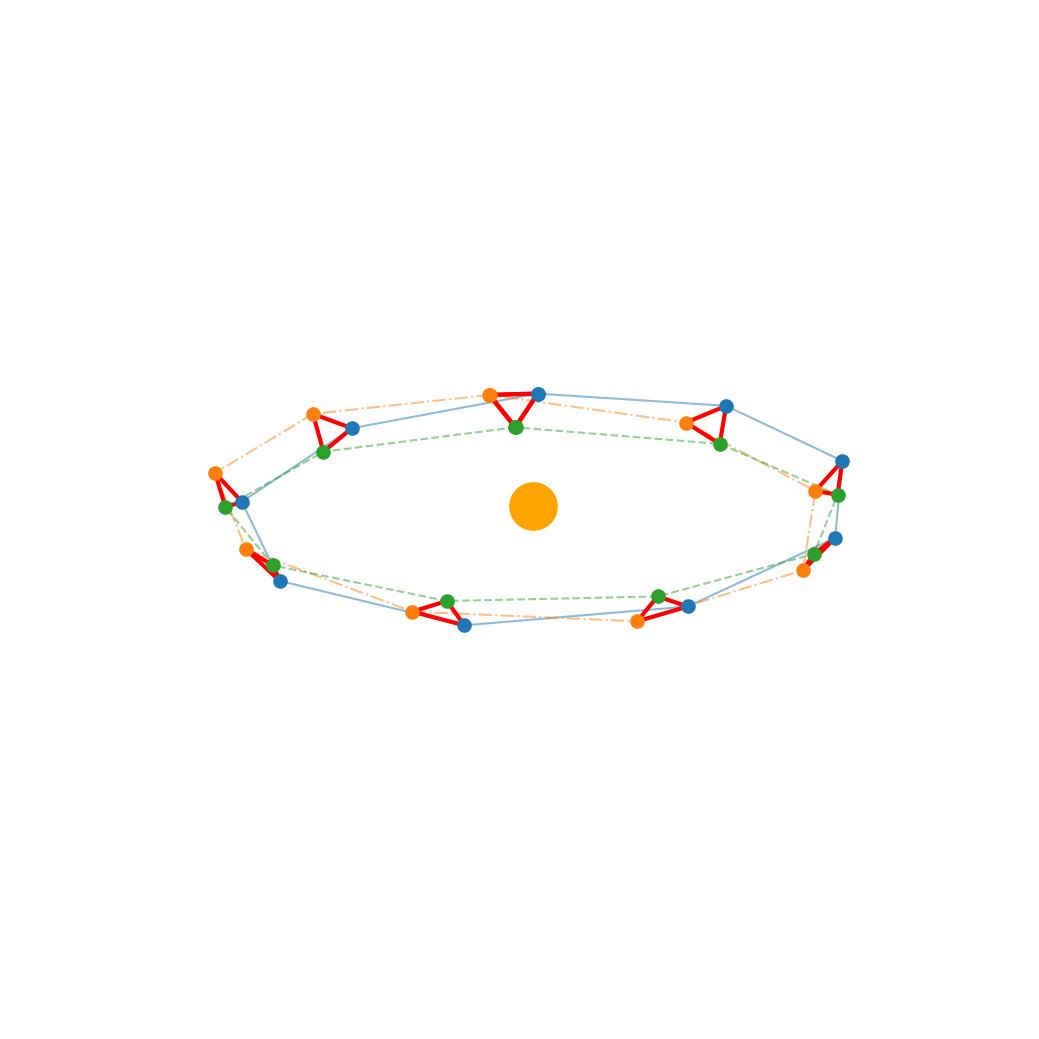

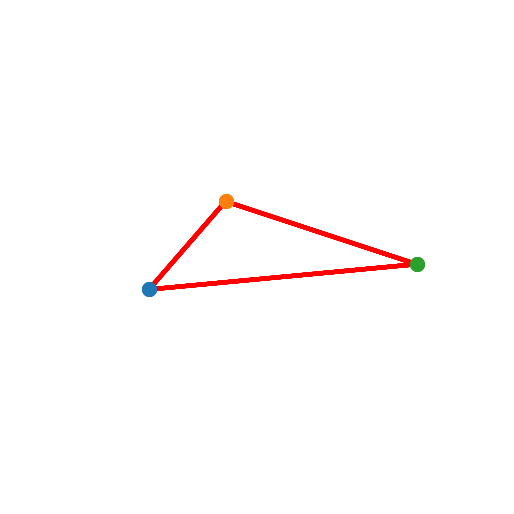

In [15]:
with h5py.File("data/processed_trajectories.h5", "r") as dset:
    t_orb_dataset = dset["t_interp"][()]
    x_orb_dataset = dset["spacecraft_positions"][()]
    v_orb_dataset = dset["spacecraft_velocities"][()]
    ltts_dataset = dset['owlt_12_23_31_13_32_21'][()]

    t_orb = t_orb_dataset
    x_orb = np.median(x_orb_dataset, axis=0)  # Use the median over all realizations
    v_orb = np.median(v_orb_dataset, axis=0)  # Use the median over all realizations
    ltts_median = np.median(ltts_dataset, axis=0)  # Use the median over all realizations
    orbital_info = {"t": t_orb, "x": x_orb, "v": v_orb, "ltt": ltts_median}

plot_orbit_3d(orbital_info, 1.0, output_file=os.path.join(PAPER_DIR, "lisa_orbit_.png"), figsize=(6*2, 2*3.5), include_sun=True)

orbits = StaticConstellation.from_armlengths(2.5e9, 2.5e9, 2.5e9)
orbital_info = {"t": t_orb, "x": orbits.compute_position(t_orb)}
plot_orbit_3d(orbital_info, 1.0, output_file=os.path.join(PAPER_DIR, "toy_orbit_.png"), figsize=(6, 3.5), include_sun=False)

In [16]:
# ── Case definitions ─────────────────────────────────────────────────────────
# Each entry:  human-readable label  →  path to the results directory
CASES = {
    "Arm-length (no boost)":          "segwo_results/static/arm1_rot0.0_trans0.0_boost0.0/",
    "Arm-length (boost)":             "segwo_results/static/arm1_rot0.0_trans0.0_boost1.0/",
    "Rotation (no boost)":     "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost0.0/",
    "Rotation (boost)":        "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost1.0/",
    "Translation (no boost)":  "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost0.0/",
    "Translation (boost)":     "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost1.0/",
    "Realistic (no boost)": "segwo_results/15.0days_evolving_boost0.0/",
    "Realistic (boost)":    "segwo_results/15.0days_evolving_boost1.0/",
}

# Reference case for the perturbation-distribution histograms
REFERENCE_CASE = "Arm-length (boost)"

In [17]:
def load_results(results_dir):
    """Load all relevant arrays from a results.h5 file."""
    hdf5_path = os.path.join(results_dir, "results.h5")
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"Missing: {hdf5_path}")
    with h5py.File(hdf5_path, "r") as hf:
        data = {
            "f":                     hf["metadata/frequencies"][()],
            "npix":                  int(hf["metadata"].attrs["npix"]),
            "nside":                 int(hf["metadata"].attrs["nside"]),
            "run_flag":              str(hf["metadata"].attrs["run_flag"]),
            "mismatch":              hf["errors/mismatch"][()],
            "strain2x_abs_error":    hf["errors/strain2x_abs_error"][()],
            "strain2x_angle_error":  hf["errors/strain2x_angle_error"][()],
            "amp_violation_ratio":   float(hf["errors"].attrs["amp_violation_ratio"]),
            "phase_violation_ratio": float(hf["errors"].attrs["phase_violation_ratio"]),
        }
        # Optional datasets (not present in all files)
        for key, path in [
            ("angle",             "errors/angle"),
            ("ltt_residuals",     "perturbed/ltt_residuals"),
            ("position_residuals","perturbed/position_residuals"),
            ("mismatch_boost",    "nominal/mismatch_boost"),
        ]:
            if path in hf:
                data[key] = hf[path][()]
    return data

all_data = {}
for label, path in CASES.items():
    try:
        all_data[label] = load_results(path)
        d = all_data[label]
        print(
            f"✓  {label:28s}  Nf={d['f'].size}, Npix={d['npix']}, "
            f"amp={d['amp_violation_ratio']:.2e}, phase={d['phase_violation_ratio']:.2e}"
        )
    except FileNotFoundError as e:
        print(f"✗  {e}")

# Common frequency axis
f = next(iter(all_data.values()))["f"]
print(f"\nFrequency range: {f.min():.2e} – {f.max():.2e} Hz  ({f.size} points)")

✓  Arm-length (no boost)         Nf=150, Npix=432, amp=3.35e-02, phase=2.61e-02
✓  Arm-length (boost)            Nf=150, Npix=432, amp=3.35e-02, phase=2.61e-02
✓  Rotation (no boost)           Nf=150, Npix=432, amp=9.44e-01, phase=2.50e-02
✓  Rotation (boost)              Nf=150, Npix=432, amp=9.44e-01, phase=2.50e-02
✓  Translation (no boost)        Nf=150, Npix=432, amp=2.27e-02, phase=1.98e-02
✓  Translation (boost)           Nf=150, Npix=432, amp=2.27e-02, phase=1.98e-02
✓  Realistic (no boost)          Nf=150, Npix=432, amp=3.96e-01, phase=1.37e-03
✓  Realistic (boost)             Nf=150, Npix=432, amp=1.30e-03, phase=0.00e+00

Frequency range: 1.00e-04 – 1.00e+00 Hz  (150 points)


## Orbital Perturbation Distributions

Histograms of the light-travel-time (LTT) residuals, spacecraft position residuals,
and orbit normal-vector angle offsets drawn from the Monte Carlo sample for the reference case.

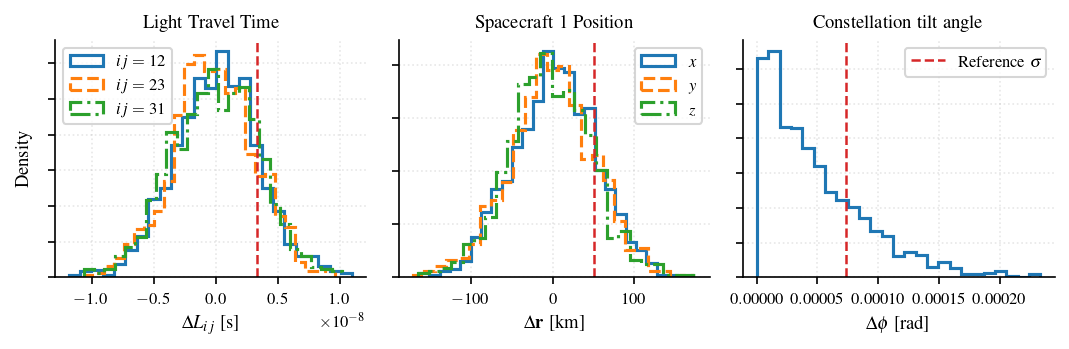

In [18]:
# "Arm (no boost)":          "segwo_results/static/arm1_rot0.0_trans0.0_boost0.0/",
# "Arm (boost)":             "segwo_results/static/arm1_rot0.0_trans0.0_boost1.0/",
# "Rotation (no boost)":     "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost0.0/",
# "Rotation (boost)":        "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost1.0/",
# "Translation (no boost)":  "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost0.0/",
# "Translation (boost)":     "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost1.0/",

ref = all_data["Arm-length (boost)"]
linestyle = ['-', '--', '-.']

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4))

# ── LTT residuals ───────────────────────────────────────────────────────────
ref = all_data["Arm-length (boost)"]
ax = axes[0]
for i in range(3):
    ax.hist(
        ref["ltt_residuals"][:, i], bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        # label=rf"$\Delta L_{{{LINKS[i]}}}$",
        label=rf"$ij = {{{LINKS[i]}}}$",
    )
ax.set_xlabel(r"$\Delta L_{ij}$ [s]")
ax.set_ylabel("Density")
ax.axvline(1.0/C, color='tab:red', ls='--', lw=1.2,)
ax.set_yticklabels([])
ax.set_title("Light Travel Time")
ax.legend()
std_ltt = np.std(ref["ltt_residuals"], axis=0)

# ── Position residuals (SC 1) ────────────────────────────────────────────────
ref = all_data["Translation (boost)"]

ax = axes[1]
for i, lbl in enumerate(["$x$", "$y$", "$z$"]):
    ax.hist(
        ref["position_residuals"][:, 0, i] / 1e3, bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        label=lbl,
    )
ax.set_xlabel(r"$\Delta \mathbf{r}$ [km]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.axvline(50.0, color='tab:red', ls='--', lw=1.2,)
ax.set_title("Spacecraft 1 Position")
ax.legend()
std_pos = np.std(ref["position_residuals"][:, 0, :], axis=0) / 1e3

# ── Orbit tilt angle ─────────────────────────────────────────────────────────
ref = all_data["Rotation (boost)"]
ax = axes[2]
dist_centroid = 2.5e9 * np.sqrt(1 / 3)
expected_sigma = 50e3 * 2.13 / dist_centroid
ax.hist(ref["angle"], bins=25, histtype='step', linewidth=1.5, density=True)
ax.axvline(expected_sigma, color='tab:red', ls='--', lw=1.2, label=r"Reference $\sigma$")
ax.set_xlabel(r"$\Delta\phi$ [rad]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Constellation tilt angle")
ax.legend()
std_angle = np.std(ref["angle"], axis=0)

plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, "static_orbit_perturbation_distributions.pdf"))
plt.show()

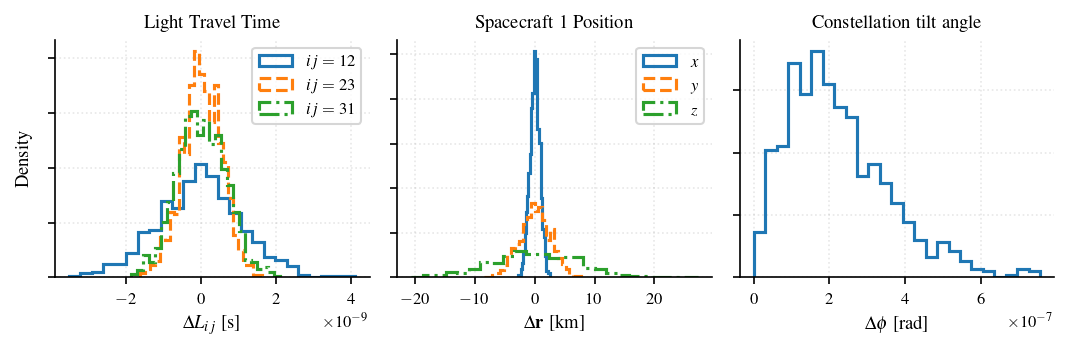

In [19]:
ref = all_data["Realistic (boost)"]
linestyle = ['-', '--', '-.']

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4))

# ── LTT residuals ───────────────────────────────────────────────────────────
ax = axes[0]
for i in range(3):
    ax.hist(
        ref["ltt_residuals"][:, i], bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        # label=rf"$\Delta L_{{{LINKS[i]}}}$",
        label=rf"$ij = {{{LINKS[i]}}}$",
    )
ax.set_xlabel(r"$\Delta L_{ij}$ [s]")
ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Light Travel Time")
ax.legend()
std_ltt_real = np.std(ref["ltt_residuals"], axis=0)

# ── Position residuals (SC 1) ────────────────────────────────────────────────
ax = axes[1]
for i, lbl in enumerate(["$x$", "$y$", "$z$"]):
    ax.hist(
        ref["position_residuals"][:, 0, i] / 1e3, bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        label=lbl,
    )
ax.set_xlabel(r"$\Delta \mathbf{r}$ [km]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Spacecraft 1 Position")
ax.legend()
std_pos_real = np.std(ref["position_residuals"][:, 0, :], axis=0) / 1e3

# ── Orbit tilt angle ─────────────────────────────────────────────────────────
ax = axes[2]
dist_centroid = 2.5e9 * np.sqrt(1 / 3)
expected_sigma = 50e3 * 2.13 / dist_centroid
ax.hist(ref["angle"], bins=25, histtype='step', linewidth=1.5, density=True)
# ax.axvline(expected_sigma, color='tab:red', ls='--', lw=1.2, label=r"Expected $\sigma$")
ax.set_xlabel(r"$\Delta\phi$ [rad]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Constellation tilt angle")
# ax.legend()
std_angle_real = np.std(ref["angle"], axis=0)

# fig.suptitle(f"Reference case: {REFERENCE_CASE}", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, "evolving_orbit_perturbation_distributions.pdf"))
plt.show()

In [20]:
# print std values for toy and realistic cases
print("Toy orbit (Arm-length boost):")
print(f"  LTT std:   {std_ltt} s")
print(f"  Position std: {std_pos} km")
print(f"  Angle std: {std_angle} rad")

print("\nRealistic orbit (Arm-length boost):")
print(f"  LTT std:   {std_ltt_real} s", std_ltt_real*C, "m")
print(f"  Position std: {std_pos_real} km")
print(f"  Angle std: {std_angle_real} rad")
# print ratios  
print("\nRatios (Realistic / Toy):")
print(f"  LTT std ratio:   {std_ltt_real / std_ltt}")
print(f"  Position std ratio: {std_pos_real / std_pos}")
print(f"  Angle std ratio: {std_angle_real / std_angle}")   

Toy orbit (Arm-length boost):
  LTT std:   [3.41492763e-09 3.29812063e-09 3.47671090e-09 3.47671090e-09
 3.29812063e-09 3.41492763e-09] s
  Position std: [50.13983051 51.78228742 50.29050993] km
  Angle std: 4.147895875987399e-05 rad

Realistic orbit (Arm-length boost):
  LTT std:   [1.12868332e-09 5.26223489e-10 6.52533832e-10 6.53330299e-10
 5.26146055e-10 1.12722809e-09] s [0.33837075 0.15775783 0.19562472 0.1958635  0.15773462 0.33793448] m
  Position std: [0.84284504 2.57724115 7.1207623 ] km
  Angle std: 1.3407226336662398e-07 rad

Ratios (Realistic / Toy):
  LTT std ratio:   [0.33051457 0.15955253 0.18768711 0.1879162  0.15952905 0.33008843]
  Position std ratio: [0.01680989 0.04977071 0.14159257]
  Angle std ratio: 0.0032322957801998427


# Link Response

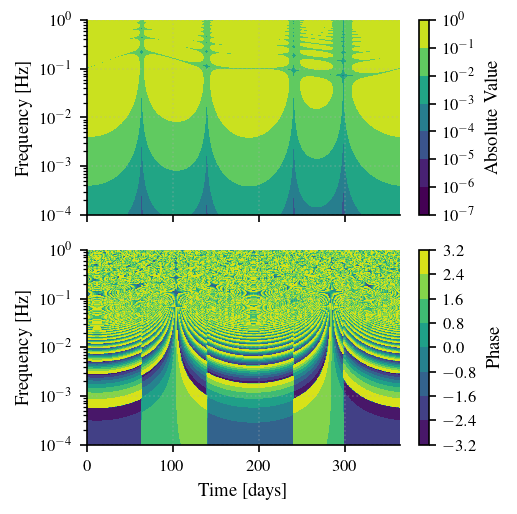

In [21]:
import matplotlib.colors as mcolors

with h5py.File("data/link_response_maps.h5", "r") as ds:
    f_ = ds["frequencies"][()]
    amp_map = ds["amp_map"][()]
    phase_map = ds["phase_map"][()]
    array_ltts = ds["array_ltts"][()]
    

fig, axes = plt.subplots(2, 1, figsize=(COL1, COL1), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f_,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f_, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("paper_plots/link_response_evolution.png", dpi=300)

## Response Evolution

Frequency values for response evolution plot: [1.00000000e-04 1.00000000e-03 1.00000000e-02 3.16227766e-02
 1.00000000e-01 3.16227766e-01 1.00000000e+00]


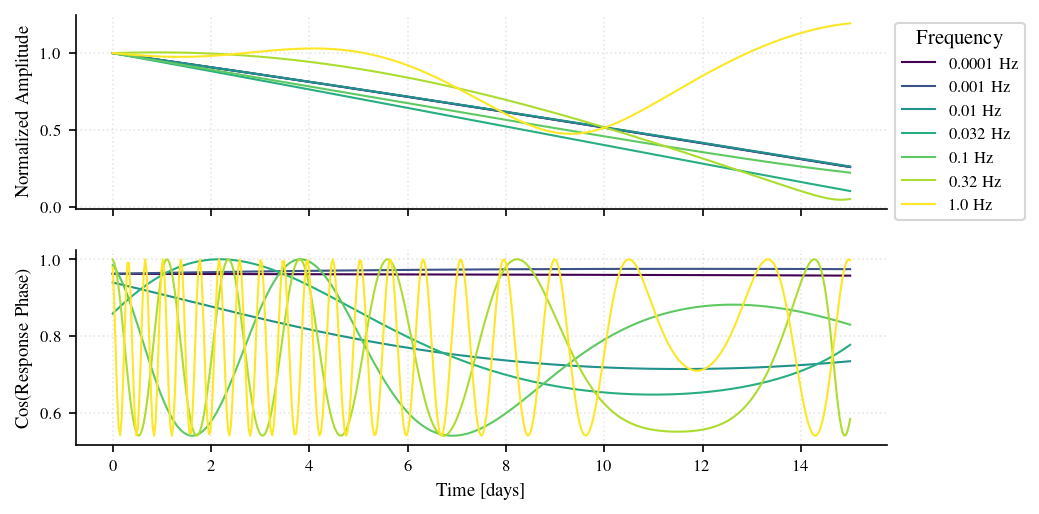

In [23]:
with h5py.File("data/response_evolution_plot.h5", "r") as ds:
    array_ltts_ = ds["array_ltts"][:]
    f_ = ds["frequencies"][:]
    phase_map_ = ds["phase_map"][:]
    amp_map_ = ds["amp_map"][:]
    phase_map_pert = ds["phase_map_pert"][:]
    amp_map_pert = ds["amp_map_pert"][:]

print("Frequency values for response evolution plot:", f_)

fig, (ax_amp, ax_phase) = plt.subplots(
    2, 1, figsize=(COL1 * 2, COL1), sharex=True
)

t_days = array_ltts_ / 86400.0
freq_vals = np.asarray(f_)

if np.all(freq_vals > 0):
    norm = mcolors.LogNorm(vmin=freq_vals.min(), vmax=freq_vals.max())
    cbar_label = "Frequency [Hz]"
else:
    norm = mcolors.Normalize(vmin=freq_vals.min(), vmax=freq_vals.max())
    cbar_label = "Frequency"

cmap = plt.cm.viridis

for i, fi in enumerate(freq_vals):
    color = cmap(norm(fi))
    ax_amp.plot(t_days, amp_map_[i]/amp_map_[i][0], color=color, lw=1, label=f"{fi:.2} Hz")
    ax_phase.plot(t_days, np.cos(phase_map_[i]), color=color, lw=1)

ax_amp.set_ylabel("Normalized Amplitude")
# ax_amp.set_title("Response amplitude evolution")
ax_amp.legend(title="Frequency", bbox_to_anchor=(1.00, 1), loc='upper left', title_fontsize=10)

ax_phase.set_ylabel(r"Cos(Response Phase)")
ax_phase.set_xlabel("Time [days]")
# ax_phase.set_title("Response phase evolution")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.tight_layout()
plt.savefig("paper_plots/response_amplitude_phase_evolution.png", dpi=300)

## Amplitude and Phase errors

In [27]:
all_data.keys()
data = all_data["Realistic (no boost)"]
data["strain2x_abs_error"].shape

(150, 432, 3, 2)

<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_99685/3512402600.py:29: SyntaxWarning: invalid escape sequence '\p'
  axs[0].loglog(f, 1e-5/f, color='k', ls=linestyle[0], lw=1.2, label="$\propto f^{-1}$", alpha=0.5)
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_99685/3512402600.py:30: SyntaxWarning: invalid escape sequence '\p'
  axs[0].loglog(f, 1e-5*f, color='k', ls=linestyle[1], lw=1.2, label="$\propto f$", alpha=0.5)


Realistic (no boost):
  Amplitude error at 1 mHz: 5.93e-03
  Phase error at 1 mHz: 3.74e-04
Realistic (boost):
  Amplitude error at 1 mHz: 7.52e-06
  Phase error at 1 mHz: 2.75e-10


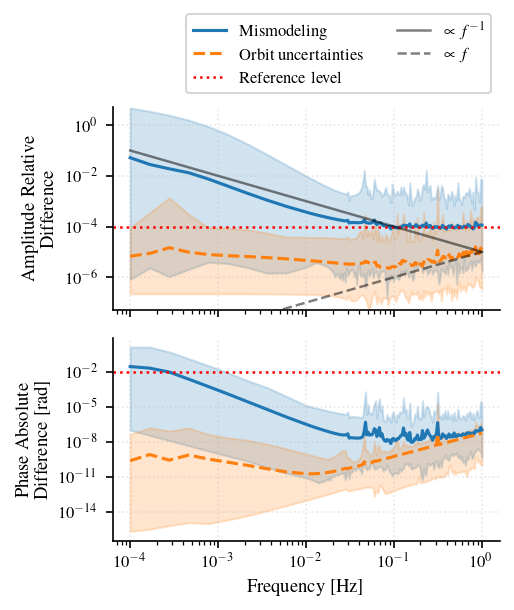

In [75]:
from plot_utils import plot_strain_errors
pols=('$h_+$', r'$h_\times$')

fig, axs = plt.subplots(2, 1, figsize=(COL1, 1.2*COL1), sharex=True)

# channel 
ch = 0
pol = 0
labels = ['Mismodeling', 'Orbit uncertainties']
linestyle = ['-', '--']
for i, name in enumerate(['Realistic (no boost)', 'Realistic (boost)']):
    data = all_data[name]
    freq_min = np.min(data["strain2x_abs_error"][:, :, ch, pol], axis=1)
    freq_max = np.max(data["strain2x_abs_error"][:, :, ch, pol], axis=1)
    axs[0].fill_between(f, freq_min, freq_max, alpha=0.2, color=f'C{i}')
    axs[0].loglog(f, np.mean(data["strain2x_abs_error"][:, :, ch, pol], axis=1), label=labels[i], color=f'C{i}', linestyle=linestyle[i])
    
    freq_min = np.min(data["strain2x_angle_error"][:, :, ch, pol], axis=1)
    freq_max = np.max(data["strain2x_angle_error"][:, :, ch, pol], axis=1)
    axs[1].fill_between(f, freq_min, freq_max, alpha=0.2, color=f'C{i}')
    axs[1].loglog(f, np.mean(data["strain2x_angle_error"][:, :, ch, pol], axis=1),label=labels[i], color=f'C{i}', linestyle=linestyle[i])
    # summary statistics
    print(f"{name}:")
    print(f"  Amplitude error at 1 mHz: {np.interp(1e-3, f, np.mean(data['strain2x_abs_error'][:, :, ch, pol], axis=1)):.2e}")
    print(f"  Phase error at 1 mHz: {np.interp(1e-3, f, np.mean(data['strain2x_angle_error'][:, :, ch, pol], axis=1)):.2e}")
    
axs[0].axhline(1e-4, color='r', ls=':', lw=1.2, label="Reference level")
axs[0].set_ylabel("Amplitude Relative \nDifference")
axs[0].loglog(f, 1e-5/f, color='k', ls=linestyle[0], lw=1.2, label="$\propto f^{-1}$", alpha=0.5)
axs[0].loglog(f, 1e-5*f, color='k', ls=linestyle[1], lw=1.2, label="$\propto f$", alpha=0.5)
axs[0].legend(ncol=2, title_fontsize=10, bbox_to_anchor=(1., 1.5))
axs[0].set_ylim(0.5e-7, 5)
axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_ylabel("Phase Absolute \nDifference [rad]")
axs[1].axhline(1e-2, color='r', ls=':', lw=1.2, label="Reference level")
# axs[1].legend(ncol=2)
plt.tight_layout()
plt.savefig("paper_plots/amplitude_phase_errors.png", dpi=300)

# 3. Mismatch vs GW Frequency

The mismatch $\mathcal{M} = 1 - \langle h_\mathrm{pert}, h_\mathrm{nom} \rangle / \sqrt{\langle h_\mathrm{pert}, h_\mathrm{pert}\rangle\,\langle h_\mathrm{nom}, h_\mathrm{nom}\rangle}$
measures the overlap degradation caused by orbit perturbations.


Arm-length (boost) - $h_+$: Mismatch at 1 mHz = 7.20e-16
Arm-length (boost) - $h_+$: Mismatch at 100 mHz = 8.09e-17
Arm-length (boost) - $h_\times$: Mismatch at 1 mHz = 6.76e-16
Arm-length (boost) - $h_\times$: Mismatch at 100 mHz = 7.34e-17
Rotation (boost) - $h_+$: Mismatch at 1 mHz = 4.12e-09
Rotation (boost) - $h_+$: Mismatch at 100 mHz = 1.16e-08
Rotation (boost) - $h_\times$: Mismatch at 1 mHz = 1.67e-08
Rotation (boost) - $h_\times$: Mismatch at 100 mHz = 1.21e-08
Translation (boost) - $h_+$: Mismatch at 1 mHz = 6.04e-13
Translation (boost) - $h_+$: Mismatch at 100 mHz = 5.67e-09
Translation (boost) - $h_\times$: Mismatch at 1 mHz = 5.70e-13
Translation (boost) - $h_\times$: Mismatch at 100 mHz = 5.35e-09
Realistic (boost) - $h_+$: Mismatch at 1 mHz = 1.90e-13
Realistic (boost) - $h_+$: Mismatch at 100 mHz = 4.03e-11
Realistic (boost) - $h_\times$: Mismatch at 1 mHz = 6.66e-14
Realistic (boost) - $h_\times$: Mismatch at 100 mHz = 4.01e-11


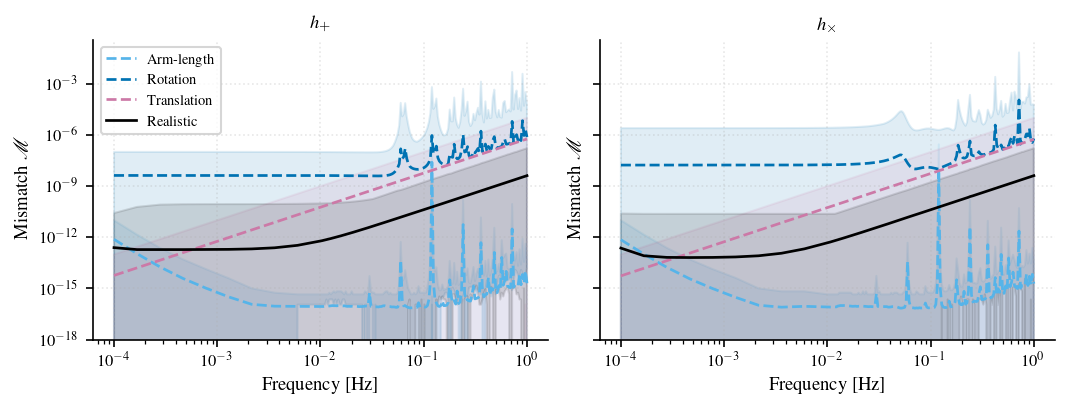

In [78]:
# Colorblind-friendly palette (Wong 2011)
STYLES = {
    # "Arm (no boost)":          dict(color="#E69F00", ls="-",  lw=1.3),
    "Arm-length (boost)":             dict(color="#56B4E9", ls="--", lw=1.3),
    # "Rotation (no boost)":     dict(color="#009E73", ls="-",  lw=1.3),
    "Rotation (boost)":        dict(color="#0072B2", ls="--", lw=1.3),
    # "Translation (no boost)":  dict(color="#D55E00", ls="-",  lw=1.3),
    "Translation (boost)":     dict(color="#CC79A7", ls="--", lw=1.3),
    # "Evolving 15d (no boost)": dict(color="#F0E442", ls="-",  lw=1.3),
    "Realistic (boost)":    dict(color="#000000", ls="-", lw=1.3),
}

fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8), sharex=True, sharey=True)

for label, style in STYLES.items():
    if label not in all_data:
        continue
    mm = np.nan_to_num(all_data[label]["mismatch"])  # (N, F, P, 2)
    freq_mean = mm.mean(axis=(0, 2))   # (F, 2)
    freq_min  = mm.min(axis=(0, 2))    # (F, 2)
    freq_max  = mm.max(axis=(0, 2))    # (F, 2)
    for j, ax in enumerate(axes):
        ax.fill_between(f, freq_min[:, j], freq_max[:, j],
                        color=style["color"], alpha=0.12)
        ax.plot(f, freq_mean[:, j],
                ls=style["ls"], lw=style["lw"], color=style["color"],
                label=label[:-8] if j == 0 else None)
        print(f"{label} - {POLS[j]}: Mismatch at 1 mHz = {np.interp(1e-3, f, freq_mean[:, j]):.2e}")
        print(f"{label} - {POLS[j]}: Mismatch at 100 mHz = {np.interp(1e-1, f, freq_mean[:, j]):.2e}")

for j, ax in enumerate(axes):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(r"Mismatch $\mathcal{M}$")
    ax.set_title(POLS[j])
    ax.set_ylim(bottom=1e-18)

axes[0].legend(fontsize=7, ncol=1, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, "mismatch_vs_frequency.pdf"))
plt.show()

## Mismatch Sky Maps

In [11]:
all_data.keys()

dict_keys(['Arm (no boost)', 'Arm (boost)', 'Rotation (no boost)', 'Rotation (boost)', 'Translation (no boost)', 'Translation (boost)', 'Realistic (no boost)', 'Realistic (boost)'])


Processing case: Realistic (boost)


/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


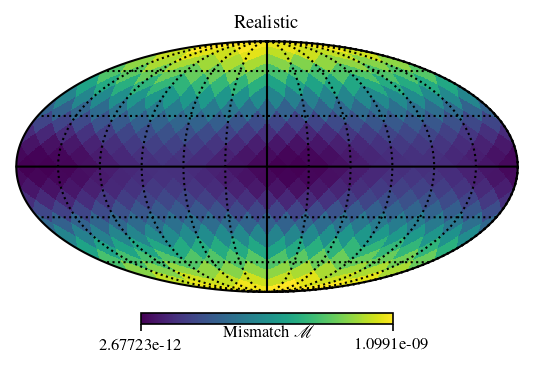


Processing case: Arm (boost)


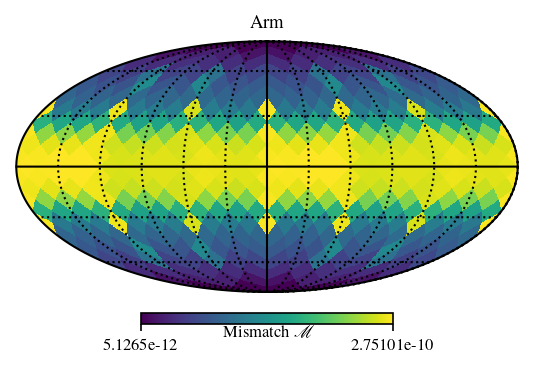


Processing case: Rotation (boost)


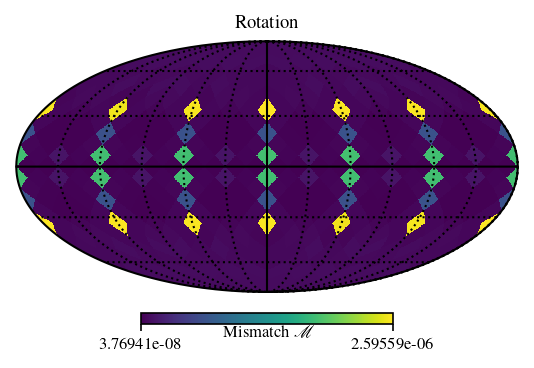


Processing case: Translation (boost)


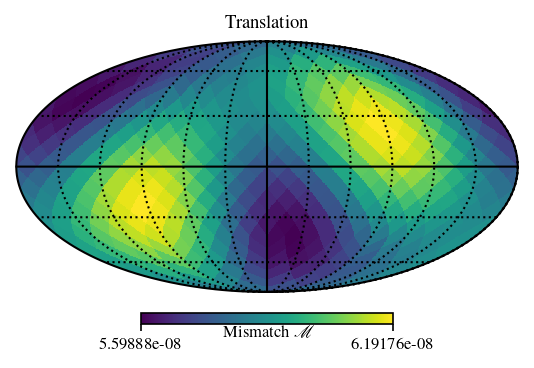

In [12]:
for MAP_CASE in ["Realistic (boost)", "Arm (boost)", "Rotation (boost)", "Translation (boost)"]:
    print("="*60)
    print(f"\nProcessing case: {MAP_CASE}")
    d    = all_data[MAP_CASE]
    mm   = np.nan_to_num(d["mismatch"])   # (N, F, P, 2)
    npix = d["npix"]

    # ── Mollweide sky maps ───────────────────────────────────────────────────────
    for j, pol in enumerate(POLS[:1]):
        sky_map = mm.mean(axis=(0, 1))[:, j]   # (P,) – max over realisations & freq
        fig = plt.figure(figsize=(COL1, 3))
        hp.mollview(
            sky_map,
            title=f"{MAP_CASE[:-8]}",
            rot=[0, 0], 
            fig=fig.number,
            unit=r"Mismatch $\mathcal{M}$",
            fontsize={'cbar_label': 8},
            # min=1e-12, max=1e-8,
        )
        hp.graticule()
        fname = f"mismatch_sky_{pol.replace('$','').replace('_','').replace('+','p').replace('\\times','x')}.pdf"
        # plt.savefig(os.path.join(PAPER_DIR, fname))
        plt.show()

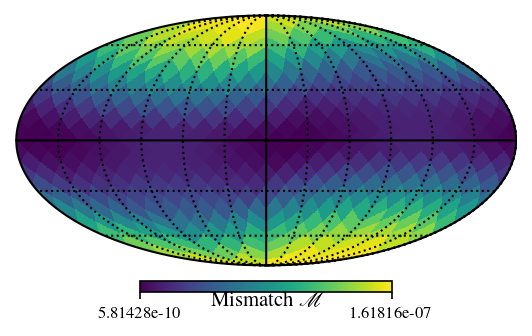

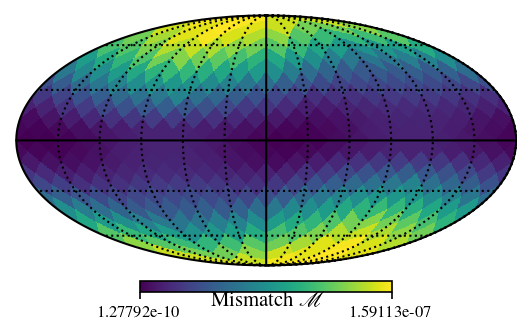

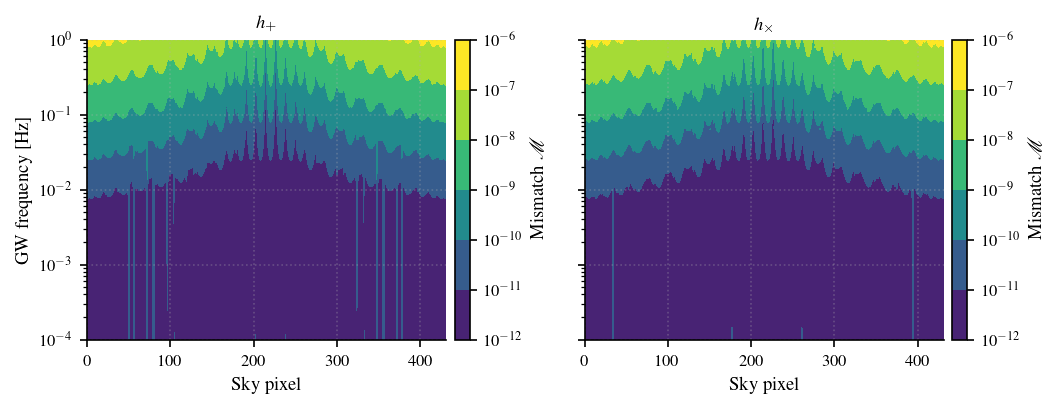

In [13]:
MAP_CASE = "Realistic (boost)"
d    = all_data[MAP_CASE]
mm   = np.nan_to_num(d["mismatch"])   # (N, F, P, 2)
npix = d["npix"]

# ── Mollweide sky maps ───────────────────────────────────────────────────────
for j, pol in enumerate(POLS):
    sky_map = mm.max(axis=(0, 1))[:, j]   # (P,) – max over realisations & freq
    fig = plt.figure(figsize=(COL1, 2.2))
    hp.mollview(
        sky_map,
        title=f"",
        rot=[0, 0], 
        fig=fig.number,
        unit=r"Mismatch $\mathcal{M}$",
        fontsize={'xlabel': 10, 'ylabel': 10, 'title': 10, 'cbar_label': 10},
    )
    hp.graticule()
    fname = f"mismatch_sky_{pol.replace('$','').replace('_','').replace('+','p').replace('\\times','x')}.pdf"
    plt.savefig(os.path.join(PAPER_DIR, fname))
    plt.show()

# ── Frequency–sky contour ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8), sharey=True)

for j, (ax, pol) in enumerate(zip(axes, POLS)):
    z = mm.max(axis=0)[:, :, j]         # (F, P) – max over realisations
    vmin = max(1e-12, float(z.min()))
    vmax = min(1.0,   float(z.max()))
    z = z.clip(vmin, vmax)
    dmin = int(np.floor(np.log10(vmin)))
    dmax = int(np.ceil(np.log10(vmax)))
    levels = np.logspace(dmin, dmax, max(2, dmax - dmin + 1))
    cf = ax.contourf(
        np.arange(npix), f, z,
        levels=levels, norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis",
    )
    ax.set_yscale("log")
    ax.set_xlabel("Sky pixel")
    ax.set_title(pol)
    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label(r"Mismatch $\mathcal{M}$")

axes[0].set_ylabel("GW frequency [Hz]")
# fig.suptitle(MAP_CASE, fontsize=8)
plt.tight_layout()
# plt.savefig(os.path.join(PAPER_DIR, "mismatch_freq_sky_contour.pdf"))
plt.show()

# Mismatch of Galactic Binary

In [122]:
results_bias_15 = {}
with h5py.File("data/gb_bias_results_15.0days.h5", "r") as f:
    # print(f.keys())
    # f["best_fit_params"]
    # f["bias"]
    for key in f.keys():
        results_bias_15[key] = f[key][()]
results_bias_15.keys()

dict_keys(['best_fit_params', 'bias', 'de_success', 'f0_vec', 'mismatch_at_bestfit', 'mismatch_at_true', 'relative_bias', 'sky_inds', 'snr', 'true_params'])

<KeysViewHDF5 ['f0_vec', 'mismatch_nonrel_vs_rel_test', 'mismatch_nonrel_vs_rel_with_nominal', 'mismatch_nonrel_vs_rel_with_perturbed', 'mismatch_perturbed_vs_nominal_with_nonrel', 'mismatch_perturbed_vs_nominal_with_rel']>


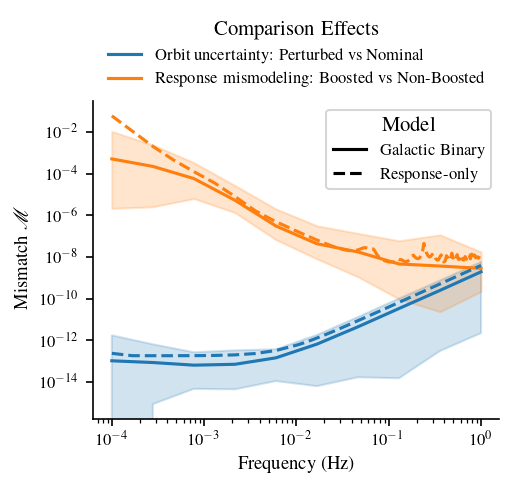

In [123]:
from matplotlib.lines import Line2D

T_OBS_DAYS = 15.
output_file = f"data/gb_mismatch_results_15.0days.h5"

mismatch = {}
with h5py.File(output_file, "r") as f:
    print(f.keys())
    f0_vec = f["f0_vec"][()]
    for key in f.keys():
        if key.startswith("mismatch_"):
            mismatch[key] = f[key][()]

labels = {
    # "mismatch_perturbed_vs_nominal_with_nonrel": "Perturbed vs Nominal Orbits (Non-Boosted Response)",
    "mismatch_perturbed_vs_nominal_with_rel": "Perturbed vs Nominal Orbits",
    # "mismatch_nonrel_vs_rel_with_perturbed": "Non-Boosted vs Boosted Response (Perturbed orbits)",
    "mismatch_nonrel_vs_rel_with_nominal": "Non-Boosted vs Boosted Response",
    # "mismatch_nonrel_vs_rel_test": "Non-Boosted. vs Boosted Response (Test)",
}

plt.figure(figsize=(COL1, COL1))
# for key in mismatch.keys():
#     if key not in list(labels.keys()):
#         continue
key = "mismatch_perturbed_vs_nominal_with_rel"
y_mean = mismatch[key].mean(axis=1)
y_min = mismatch[key].min(axis=1)
y_max = mismatch[key].max(axis=1)
plt.fill_between(f0_vec, y_min, y_max, alpha=0.2, color='C0')
plt.plot(f0_vec, y_mean, '-', label=labels[key], color='C0')

key = "mismatch_nonrel_vs_rel_with_nominal"
y_mean = mismatch[key].mean(axis=1)
y_min = mismatch[key].min(axis=1)
y_max = mismatch[key].max(axis=1)
plt.fill_between(f0_vec, y_min, y_max, alpha=0.2, color='C1')
plt.plot(f0_vec, y_mean, '-', label=labels[key], color='C1')


f = all_data["Realistic (no boost)"]["f"]
plt.loglog(f, np.mean(all_data["Realistic (no boost)"]["mismatch"],axis=(0,2))[:,0], ls='--', color='C1')
# plt.fill_between(f, np.min(all_data["Realistic (no boost)"]["mismatch"],axis=(0,2))[:,0], 
#                  np.max(all_data["Realistic (no boost)"]["mismatch"],axis=(0,2))[:,0], 
#                  alpha=0.1, color='C1')
plt.loglog(f, np.mean(all_data["Realistic (boost)"]["mismatch"],axis=(0,2))[:,0], ls='--', color='C0')
# plt.fill_between(f, np.min(all_data["Realistic (boost)"]["mismatch"],axis=(0,2))[:,0], 
#                  np.max(all_data["Realistic (boost)"]["mismatch"],axis=(0,2))[:,0], 
#                  alpha=0.1, color='C0')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Mismatch $\mathcal{M}$")
ax = plt.gca()

style_handles = [
    Line2D([0], [0], color='k', ls='-', label='Galactic Binary'),
    Line2D([0], [0], color='k', ls='--', label='Response-only'),
]

color_handles = [
    Line2D([0], [0], color='C0', lw=1.5, label='Orbit uncertainty: Perturbed vs Nominal'),
    Line2D([0], [0], color='C1', lw=1.5, label='Response mismodeling: Boosted vs Non-Boosted'),
]

legend_style = ax.legend(handles=style_handles, title="Model", loc="upper right", title_fontsize=10)
ax.add_artist(legend_style)
ax.legend(handles=color_handles, title="Comparison Effects", loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=1, title_fontsize=10, frameon=True, framealpha=0.0)
plt.grid()
plt.tight_layout()
# plt.savefig(f"gb_mismatch_plot_{T_OBS_DAYS:.1f}days.png", dpi=300)
plt.savefig(os.path.join(PAPER_DIR, f"gb_mismatch_plot.png"), dpi=300, bbox_inches='tight')
plt.show()



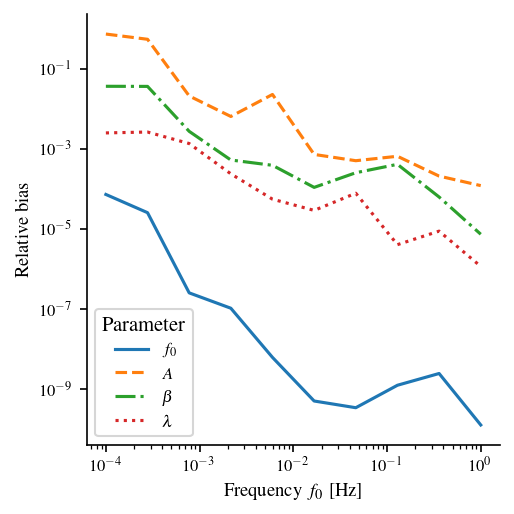

In [124]:
plt.figure(figsize=(COL1, COL1))

plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,0]), label='$f_0$', ls='-')
plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,2]), label='$A$', ls='--')
plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,3]), label=r'$\beta$', ls='-.')
plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,4]), label=r'$\lambda$', ls=':')
plt.xlabel("Frequency $f_0$ [Hz]")
plt.ylabel("Relative bias")
plt.xscale("log")
plt.yscale("log")
plt.legend(title="Parameter", loc="lower left", title_fontsize=10)
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, f"gb_parameter_biases.png"), dpi=300, bbox_inches='tight')
plt.show()

<Figure size 262.5x262.5 with 0 Axes>

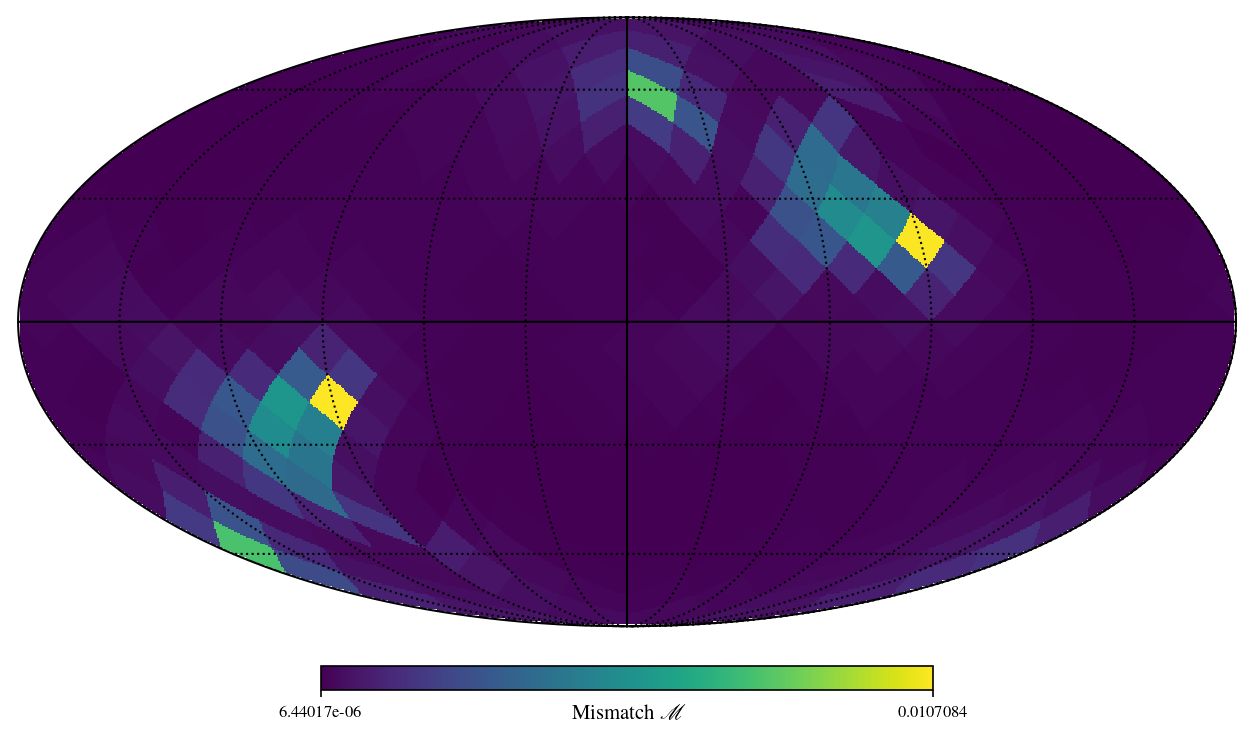

In [125]:
labels = {
    # "mismatch_perturbed_vs_nominal_with_nonrel": "Perturbed vs Nominal Orbits (Non-Boosted Response)",
    "mismatch_perturbed_vs_nominal_with_rel": "Perturbed vs Nominal Orbits",
    # "mismatch_nonrel_vs_rel_with_perturbed": "Non-Boosted vs Boosted Response (Perturbed orbits)",
    "mismatch_nonrel_vs_rel_with_nominal": "Non-Boosted vs Boosted Response",
    # "mismatch_nonrel_vs_rel_test": "Non-Boosted. vs Boosted Response (Test)",
}

key = "mismatch_perturbed_vs_nominal_with_rel"
key = "mismatch_nonrel_vs_rel_with_nominal"

plt.figure(figsize=(COL1/2,COL1/2))
hp.mollview(
        mismatch[key].max(axis=0),
        title=f"",
        rot=[0, 0], 
        unit=r"Mismatch $\mathcal{M}$",
        fontsize={'xlabel': 10, 'ylabel': 10, 'title': 10, 'cbar_label': 10},
    )
hp.graticule()

In [126]:
results_bias_365 = {}
with h5py.File("data/gb_bias_results_365.0days.h5", "r") as f:
    # print(f.keys())
    # f["best_fit_params"]
    # f["bias"]
    for key in f.keys():
        results_bias_365[key] = f[key][()]
results_bias_365.keys()

dict_keys(['best_fit_params', 'bias', 'de_success', 'f0_vec', 'mismatch_at_bestfit', 'mismatch_at_true', 'relative_bias', 'sky_inds', 'snr', 'true_params'])

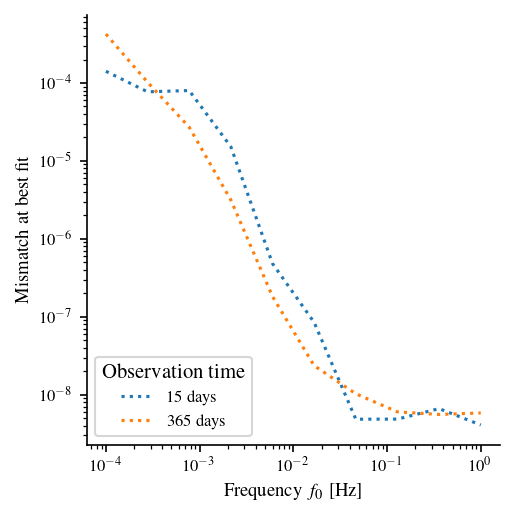

In [130]:
plt.figure(figsize=(COL1, COL1))
plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['mismatch_at_bestfit']), 'C0:', label='15 days')
plt.loglog(results_bias_365['f0_vec'], np.abs(results_bias_365['mismatch_at_bestfit']), 'C1:', label='365 days')
plt.xlabel("Frequency $f_0$ [Hz]")
plt.ylabel("Mismatch at best fit")
plt.xscale("log")
plt.yscale("log")
plt.legend(title="Observation time", loc="lower left", title_fontsize=10)
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, f"gb_mismatch_at_bestfit_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

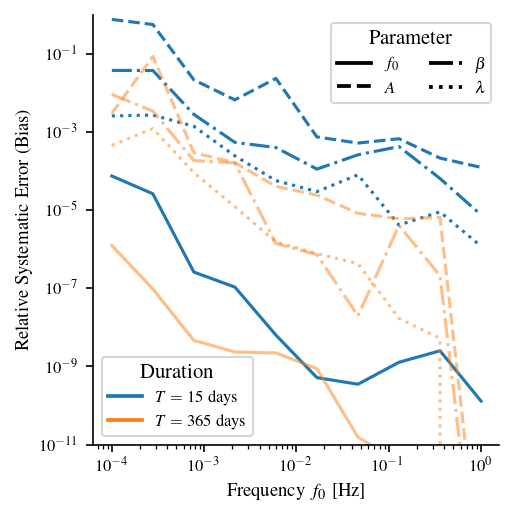

In [141]:
plt.figure(figsize=(COL1, COL1))

plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,0]), label='$f_0$', ls='-', color='C0')
plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,2]), label='$A$', ls='--', color='C0')
plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,3]), label=r'$\beta$', ls='-.', color='C0')
plt.loglog(results_bias_15['f0_vec'], np.abs(results_bias_15['relative_bias'][:,4]), label=r'$\lambda$', ls=':', color='C0')

plt.loglog(results_bias_365['f0_vec'], np.abs(results_bias_365['relative_bias'][:,0]), ls='-', color='C1', alpha=0.5)
plt.loglog(results_bias_365['f0_vec'], np.abs(results_bias_365['relative_bias'][:,2]), ls='--', color='C1', alpha=0.5)
plt.loglog(results_bias_365['f0_vec'], np.abs(results_bias_365['relative_bias'][:,3]), ls='-.', color='C1', alpha=0.5)
plt.loglog(results_bias_365['f0_vec'], np.abs(results_bias_365['relative_bias'][:,4]), ls=':', color='C1', alpha=0.5)
plt.xlabel("Frequency $f_0$ [Hz]")
plt.ylabel("Relative Systematic Error (Bias)")
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-11, 1)
ax = plt.gca()

duration_handles = [
    Line2D([0], [0], color='C0', lw=1.8, label=r'$T=15$ days'),
    Line2D([0], [0], color='C1', lw=1.8, label=r'$T=365$ days'),
]

parameter_handles = [
    Line2D([0], [0], color='k', lw=1.8, ls='-',  label=r'$f_0$'),
    Line2D([0], [0], color='k', lw=1.8, ls='--', label=r'$A$'),
    Line2D([0], [0], color='k', lw=1.8, ls='-.', label=r'$\beta$'),
    Line2D([0], [0], color='k', lw=1.8, ls=':',  label=r'$\lambda$'),
]

leg1 = ax.legend(handles=duration_handles, title="Duration", loc="lower left", title_fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=parameter_handles, title="Parameter", loc="upper right", title_fontsize=10, ncol=2)
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, f"gb_parameter_biases.png"), dpi=300, bbox_inches='tight')
plt.show()

# MCMC check

In [16]:
import corner
from eryn.backends import HDFBackend
# data_rel = HDFBackend("backend_run_rel.h5")
data_nonrel = HDFBackend("backend_run_nonrel.h5")


(96000, 8), (96000,)


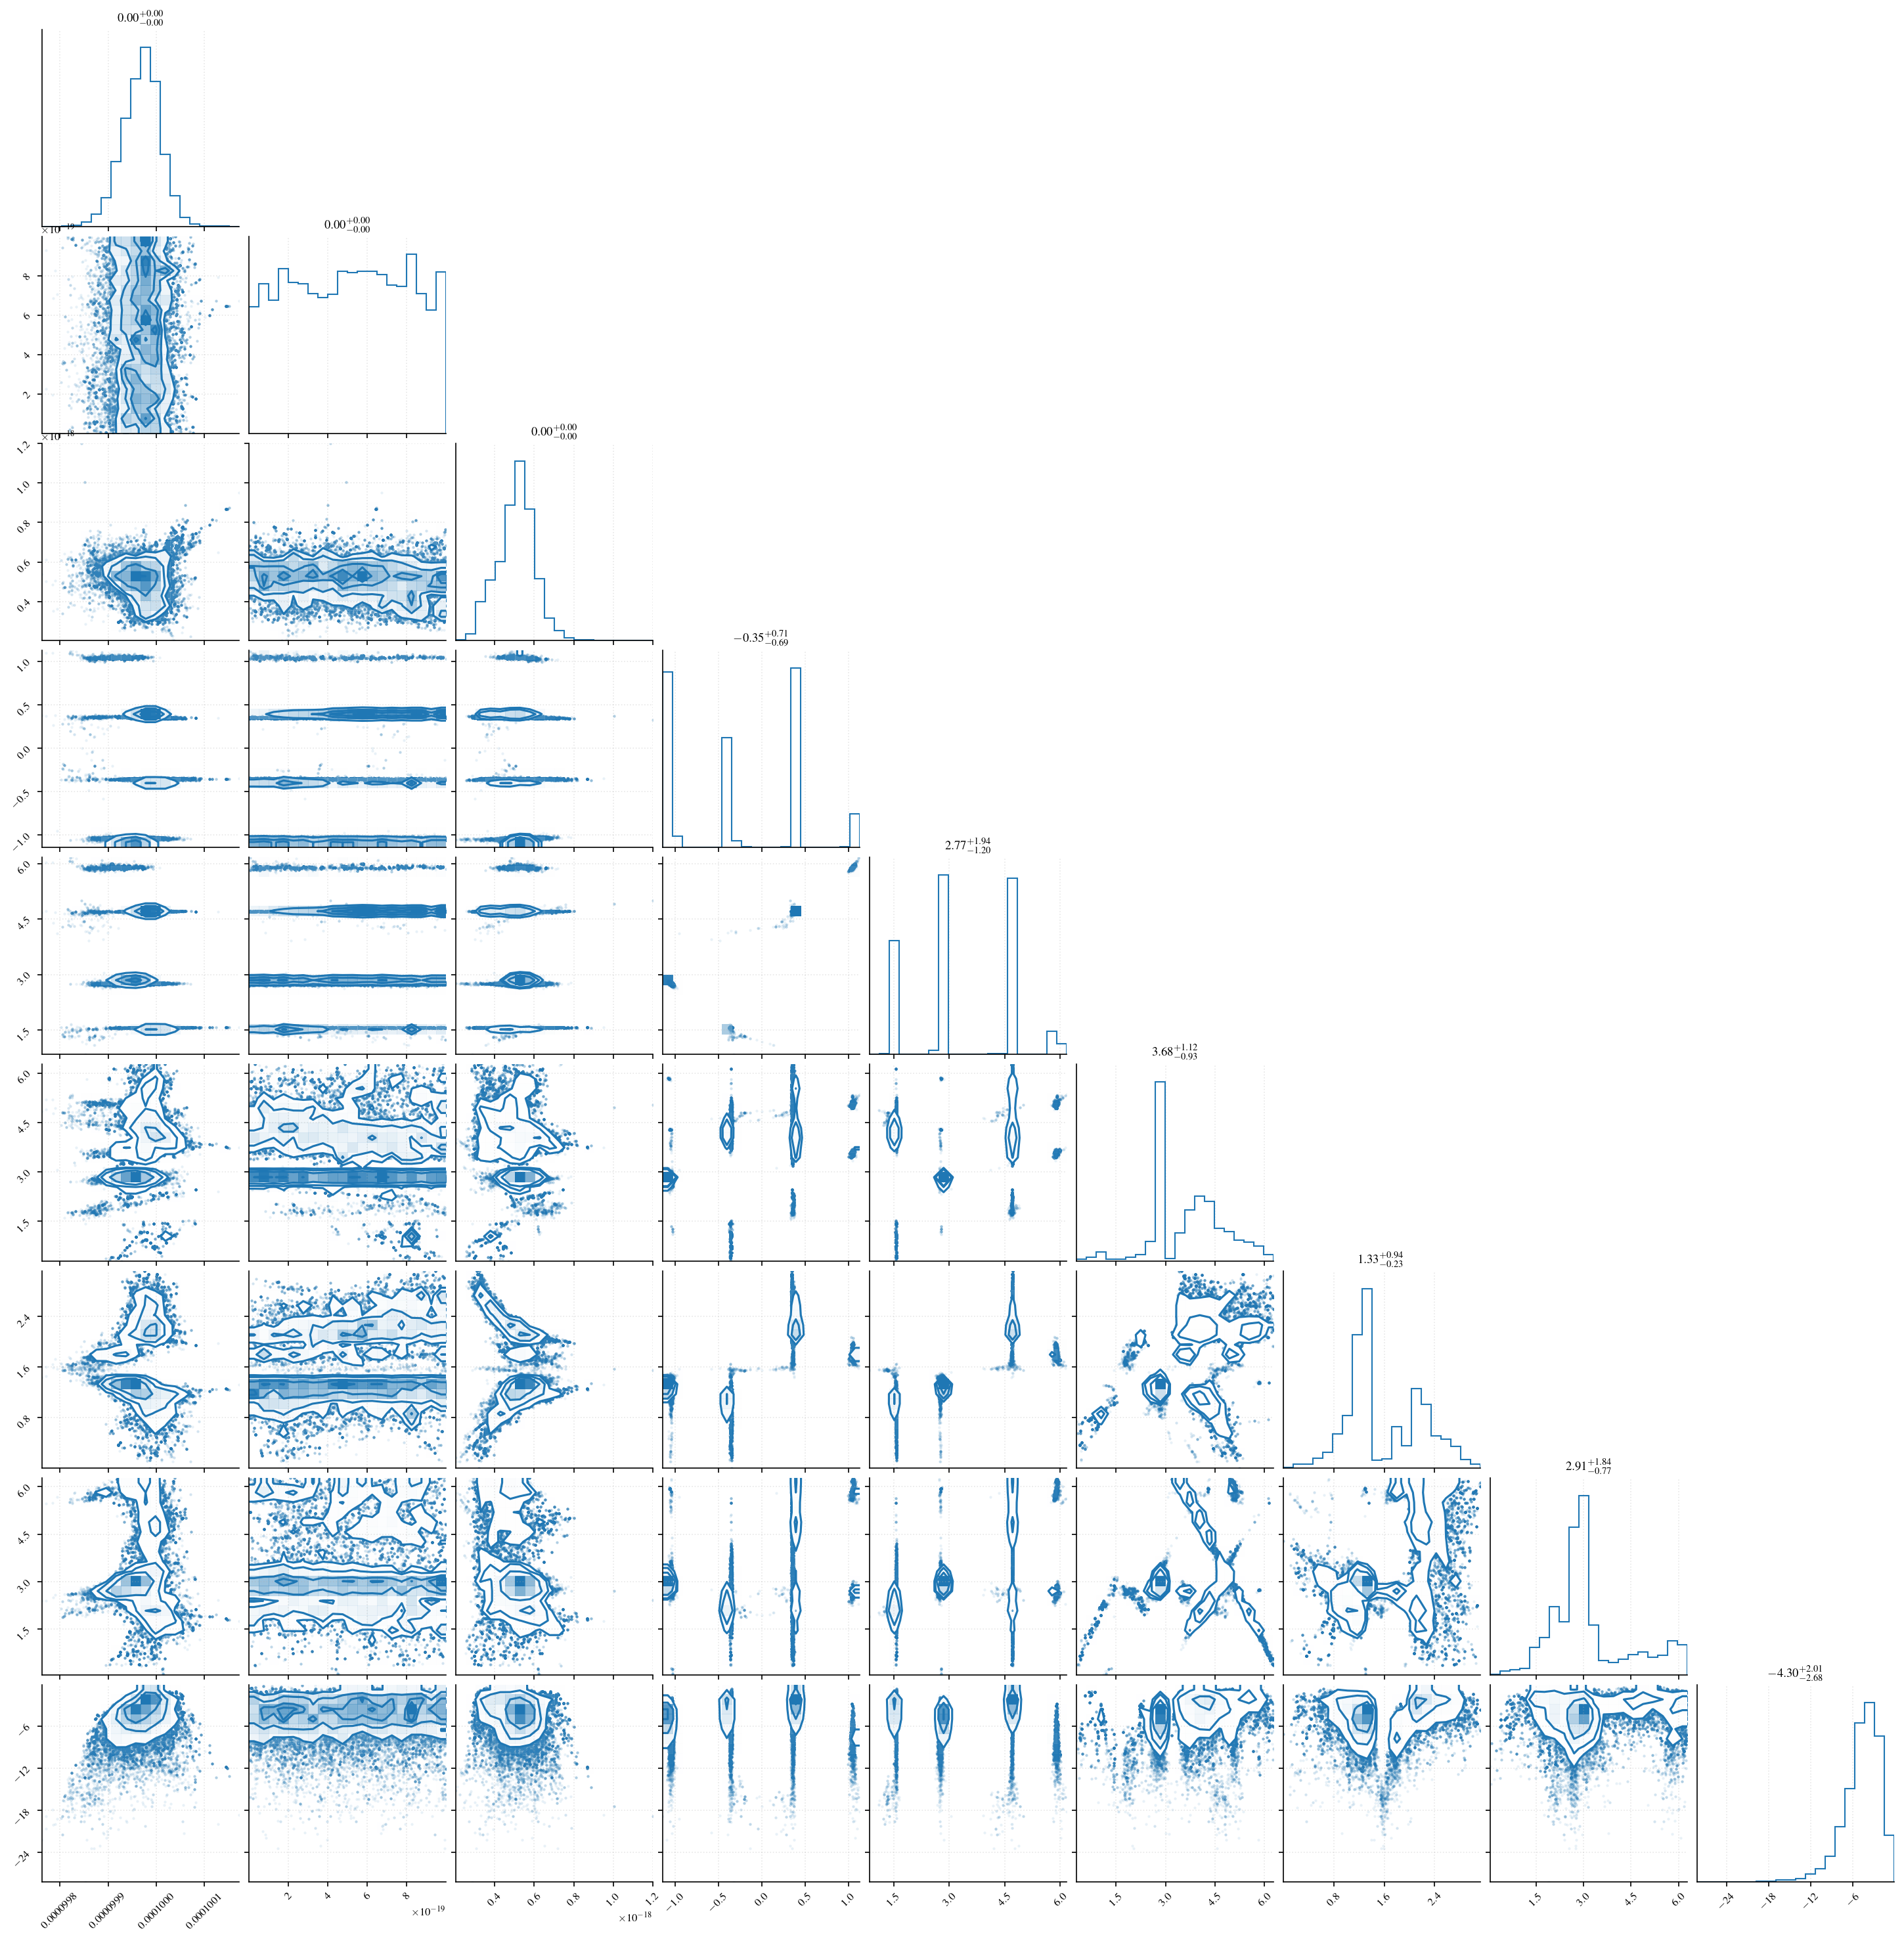

In [17]:

colors = ['C0', 'C1']
fig = None
for data, color in zip([data_nonrel], colors):
    inds = data.get_inds(discard=2000)["gb"][:,0]
    samples = data.get_chain(discard=2000)["gb"][:,0][inds]
    logl = data.get_log_like(discard=2000)[:,0][inds[:,:,0]]
    print(f"{samples.shape}, {logl.shape}")
    samp_log = np.hstack((samples, logl[:,None]))
    fig = corner.corner(samp_log, show_titles=True, fig=fig, color=color, weights=np.ones(len(samples))/len(samples))
plt.show()

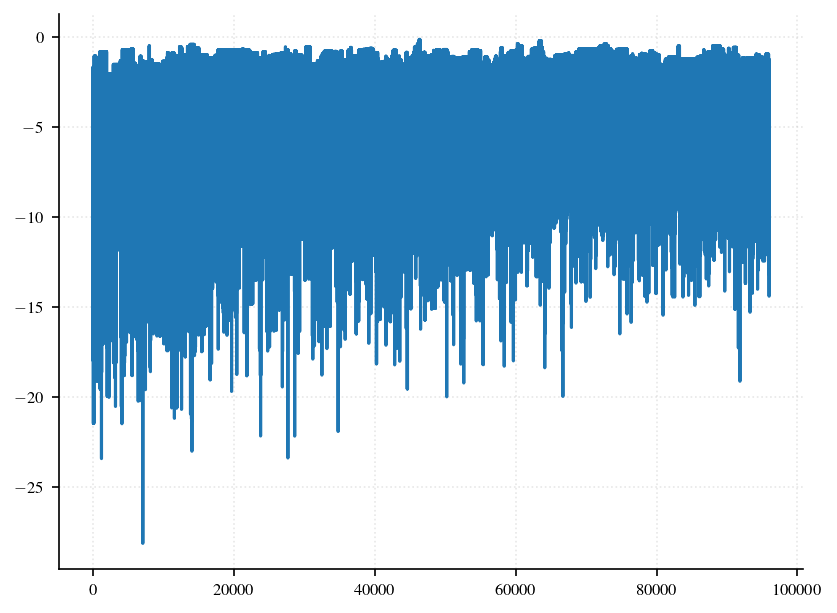

In [18]:
plt.plot(logl)